In [29]:
import numpy as np
import matplotlib.pyplot as plt


Code1.11: Randomized SVD algorithm.

In [30]:
# input:
# X: matrix
# r: rank
# p: oversampling
# q: power iteration

# output: SVD

def rSVD(X,r,p,q):
    P = np.random.randn(X.shape[1],r+p)
    # Step1:  Z  = X @ P
    Z = X @ P
    for i in range(q):
        Z = X @ (X.T @ Z)
    Q,R = np.linalg.qr(Z,mode='reduced')
    
    Y = Q.T @ X
    U_Y, Sigma, V_S_T = np.linalg.svd(Y,full_matrices=False)
    U = Q @ U_Y
    
    return U,Sigma,V_S_T

Code1.12: Compute the randomized SVD of high-resolution image

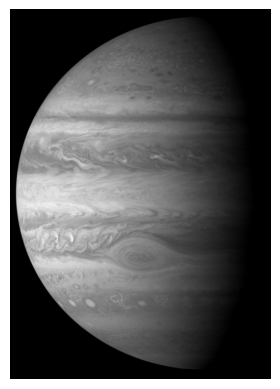

In [31]:
A = plt.imread("../../DATA/jupiter.jpg")
X = np.mean(A,axis=2)
plt.imshow(X,cmap='gray')
plt.axis('off')
plt.show()

In [32]:
U, Sigma, V_T = np.linalg.svd(X,full_matrices=False)

In [33]:
r = 400
q = 1
p = 5
r_U, r_Sigma, r_V_T = rSVD(X,r,p,q)

In [34]:
X_SVD = U[:,:r+1] @ np.diag(Sigma[:r+1]) @ V_T[:r+1,:]
err_SVD = np.linalg.norm(X_SVD-X,ord=2) / np.linalg.norm(X,ord=2)

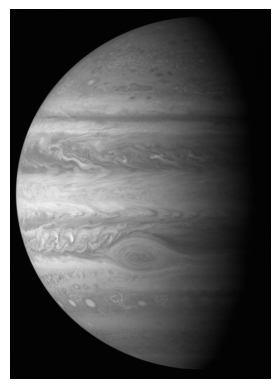

In [35]:
plt.imshow(X_SVD,cmap='gray')
plt.axis('off')
plt.show()

In [36]:
X_rSVD = r_U[:,:r+1] @ np.diag(r_Sigma[:r+1]) @ r_V_T[:r+1,:]
err_rSVD = np.linalg.norm(X_rSVD-X,ord=2) / np.linalg.norm(X,ord=2)

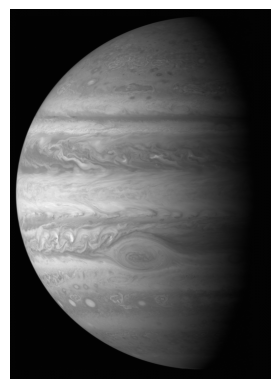

In [37]:
plt.imshow(X_rSVD,cmap='gray')
plt.axis('off')
plt.show()